# LightGBM con Feature Engineering Avanzado

Modelo tabular mejorado con:
- Todos los features disponibles
- Target encoding OOF de zipcode y homeType (sin leakage)
- Estadísticas de vecindario por zip
- Features de ratio e interacciones
- 5-fold cross-validation con early stopping

**OOF MAPE estimado: ~25.77%**

## 1. Imports y carga de datos

In [20]:
import os
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

# Asegurar que el working directory sea la raiz del proyecto
if not os.path.exists("data/tabular/train_processed.csv"):
    os.chdir("..")

train = pd.read_csv("data/tabular/train_processed.csv")
test  = pd.read_csv("data/tabular/test_processed.csv")

TARGET    = "log_price"          # log1p(lastSoldPrice_hpi_adjusted)
PRICE_COL = "lastSoldPrice_hpi_adjusted"

print(f"Train: {train.shape}  |  Test: {test.shape}")

Train: (11840, 46)  |  Test: (5038, 44)


## 2. Feature engineering

In [21]:
def add_features(df):
    df = df.copy()

    # Ratios de area
    df["area_per_bed"]     = df["livingArea"] / (df["bedrooms"].clip(lower=1))
    df["area_per_bath"]    = df["livingArea"] / (df["bathrooms"].clip(lower=1))
    df["living_lot_ratio"] = df["livingArea"] / (df["lotAreaValue"].clip(lower=1))

    # Interacciones con atributos premium
    df["waterfront_area"] = df["has_waterfront"] * df["livingArea"]
    df["pool_area"]       = df["has_pool"]       * df["livingArea"]
    df["garage_area"]     = df["has_garage"]     * df["livingArea"]

    # HOA como señal de calidad del edificio
    df["log_hoa_fee"] = np.log1p(df["hoa_fee_monthly"])

    # Depreciacion no lineal por antiguedad
    df["property_age_sq"] = df["property_age"] ** 2

    # Distancia al centro de Miami
    df["dist_miami_center"] = np.sqrt(
        (df["latitude"]  - 25.774) ** 2 +
        (df["longitude"] - (-80.190)) ** 2
    )

    # Eficiencia fiscal
    df["tax_efficiency"] = df["latest_tax_paid"] / (df["latest_tax_value"].clip(lower=1))

    # Nuevas interacciones financieras (basadas en importancia de variables)
    df["listing_vs_tax"]    = df["last_listing_price"] / df["taxAssessedValue"].clip(lower=1)
    df["tax_per_sqft"]      = df["taxAssessedValue"]   / df["livingArea"].clip(lower=1)
    df["listing_per_sqft"]  = df["last_listing_price"] / df["livingArea"].clip(lower=1)
    df["tax_to_listing"]    = df["taxAssessedValue"]   / df["last_listing_price"].clip(lower=1)

    # Proxy de vocabulario en descripcion
    df["avg_word_length"]   = df["desc_length"] / (df["desc_word_count"].clip(lower=1))

    return df

train = add_features(train)
test  = add_features(test)
print("Features agregados:", train.shape)

Features agregados: (11840, 61)


## 3. Estadísticas de vecindario por ZIP

In [22]:
def add_zip_stats(train_df, test_df):
    zip_stats = train_df.groupby("zipcode").agg(
        zip_median_price     = (PRICE_COL,             "median"),
        zip_mean_living_area = ("livingArea",           "mean"),
        zip_median_tax       = ("taxAssessedValue",     "median"),
        zip_median_listing   = ("last_listing_price",   "median"),
        zip_count            = ("zpid",                 "count"),
        zip_pool_rate        = ("has_pool",             "mean"),
        zip_waterfront_rate  = ("has_waterfront",       "mean"),
    ).reset_index()

    train_df = train_df.merge(zip_stats, on="zipcode", how="left")
    test_df  = test_df.merge(zip_stats,  on="zipcode", how="left")

    # Desvio del precio de listado respecto a la mediana del ZIP
    train_df["listing_vs_zip_median"] = (
        train_df["last_listing_price"] / train_df["zip_median_listing"].clip(lower=1)
    )
    test_df["listing_vs_zip_median"] = (
        test_df["last_listing_price"] / test_df["zip_median_listing"].clip(lower=1)
    )
    return train_df, test_df

train, test = add_zip_stats(train, test)
print("ZIP stats agregados.")

ZIP stats agregados.


## 4. Target encoding global (para el modelo final sobre test)

In [23]:
def add_target_encoding_global(train_df, test_df, cols, target, smoothing=100):
    """Encoding global calculado sobre todo train — se usa solo para predecir test.
    Dentro del CV se recalcula por fold para evitar leakage."""
    global_mean = train_df[target].mean()
    for col in cols:
        stats = train_df.groupby(col, observed=True)[target].agg(["mean", "count"])
        stats["encoded"] = (
            (stats["mean"] * stats["count"] + global_mean * smoothing)
            / (stats["count"] + smoothing)
        )
        enc_map = stats["encoded"].to_dict()
        train_df[f"{col}_te"] = train_df[col].astype(object).map(enc_map).astype(float).fillna(global_mean)
        test_df[f"{col}_te"]  = test_df[col].astype(object).map(enc_map).astype(float).fillna(global_mean)
    return train_df, test_df

train, test = add_target_encoding_global(
    train, test, ["zipcode", "homeType", "zip_3digit"], TARGET
)
print("Target encoding global calculado.")

Target encoding global calculado.


## 5. Definicion de features y parametros

In [24]:
BASE_FEATURES = [
    # Core
    "bedrooms", "bathrooms", "livingArea", "yearBuilt",
    "latitude", "longitude", "lotAreaValue", "photoCount",
    # Tax & financial
    "taxAssessedValue", "propertyTaxRate",
    "latest_tax_value", "latest_tax_paid", "num_tax_records",
    "last_listing_price",
    # Transaction
    "num_sales", "num_price_changes",
    # Schools
    "avg_school_rating", "max_school_rating", "min_school_distance",
    # Atributos
    "has_hoa", "hoa_fee_monthly", "log_hoa_fee",
    "has_pool", "has_garage", "has_waterfront",
    # Derived originales
    "property_age", "property_age_sq",
    "bath_to_bed_ratio", "log_living_area", "log_lot_area",
    # Ratios de area
    "area_per_bed", "area_per_bath", "living_lot_ratio",
    # Interacciones premium
    "waterfront_area", "pool_area", "garage_area",
    # Geograficos
    "dist_miami_center",
    # Fiscal
    "tax_efficiency",
    # Nuevas interacciones financieras
    "listing_vs_tax", "tax_per_sqft", "listing_per_sqft", "tax_to_listing",
    # Descripcion
    "desc_length", "desc_word_count", "desc_is_boilerplate",
    "desc_mentions_renovated", "desc_mentions_pool",
    "desc_mentions_view", "desc_mentions_new",
    "avg_word_length",
    # ZIP stats
    "zip_median_price", "zip_mean_living_area", "zip_median_tax",
    "zip_median_listing", "zip_count", "zip_pool_rate", "zip_waterfront_rate",
    "listing_vs_zip_median",
    # Target encoding
    "zipcode_te", "homeType_te", "zip_3digit_te",
    # Categoricas crudas
    "homeType", "zipcode",
]

CAT_FEATURES = ["homeType", "zipcode"]
for col in CAT_FEATURES:
    train[col] = train[col].astype("category")
    test[col]  = test[col].astype("category")

PARAMS = dict(
    n_estimators=3000,
    learning_rate=0.02,
    num_leaves=127,
    min_child_samples=20,
    feature_fraction=0.75,
    bagging_fraction=0.8,
    bagging_freq=1,
    reg_alpha=0.1,
    reg_lambda=0.5,
    random_state=42,
    verbosity=-1,
)

print(f"Total features: {len(BASE_FEATURES)}")

Total features: 63


## 6. Cross-validation 5 folds con target encoding OOF

In [25]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_pred_log      = np.zeros(len(train))
test_pred_logs    = np.zeros((len(test), 5))
feat_importances  = np.zeros(len(BASE_FEATURES))

print("=" * 60)
print(f"{'Fold':>5}  {'MAPE train':>10}  {'MAPE val':>10}  {'best iter':>10}")
print("=" * 60)

for fold, (tr_idx, val_idx) in enumerate(kf.split(train)):
    tr_df  = train.iloc[tr_idx].copy()
    val_df = train.iloc[val_idx].copy()

    # Target encoding calculado solo con datos del fold de entrenamiento
    global_mean = tr_df[TARGET].mean()
    smoothing   = 100
    for col in ["zipcode", "homeType", "zip_3digit"]:
        stats = tr_df.groupby(col, observed=True)[TARGET].agg(["mean", "count"])
        stats["encoded"] = (
            (stats["mean"] * stats["count"] + global_mean * smoothing)
            / (stats["count"] + smoothing)
        )
        enc_map = stats["encoded"].to_dict()
        tr_df[f"{col}_te"]  = tr_df[col].astype(object).map(enc_map).astype(float).fillna(global_mean)
        val_df[f"{col}_te"] = val_df[col].astype(object).map(enc_map).astype(float).fillna(global_mean)

    model = lgb.LGBMRegressor(**PARAMS)
    model.fit(
        tr_df[BASE_FEATURES], tr_df[TARGET],
        eval_set=[(val_df[BASE_FEATURES], val_df[TARGET])],
        eval_metric="mae",
        callbacks=[
            lgb.early_stopping(stopping_rounds=80, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
        categorical_feature=CAT_FEATURES,
    )

    val_pred_log = model.predict(val_df[BASE_FEATURES])
    oof_pred_log[val_idx] = val_pred_log

    val_price = val_df[PRICE_COL].values
    mape_val  = np.mean(np.abs((val_price - np.expm1(val_pred_log)) / val_price)) * 100

    tr_price = tr_df[PRICE_COL].values
    mape_tr  = np.mean(np.abs((tr_price - np.expm1(model.predict(tr_df[BASE_FEATURES]))) / tr_price)) * 100

    print(f"  {fold+1:>3}  {mape_tr:>9.2f}%  {mape_val:>9.2f}%  {model.best_iteration_:>10}")

    test_pred_logs[:, fold]  = model.predict(test[BASE_FEATURES])
    feat_importances        += model.feature_importances_

 Fold  MAPE train    MAPE val   best iter
    1      13.17%      24.19%         343
    2      12.91%      26.48%         343
    3       9.10%      26.14%         577
    4      12.24%      26.68%         377
    5       9.74%      24.94%         535


## 7. Metricas OOF finales

In [26]:
oof_price  = np.expm1(oof_pred_log)
true_price = train[PRICE_COL].values
oof_mape   = np.mean(np.abs((true_price - oof_price) / true_price)) * 100
oof_mae    = mean_absolute_error(true_price, oof_price)

print("=" * 60)
print(f"\nOOF MAPE: {oof_mape:.2f}%  (estimacion real del MAPE en test)")
print(f"OOF MAE:  ${oof_mae:,.0f}")


OOF MAPE: 25.69%  (estimacion real del MAPE en test)
OOF MAE:  $115,938


## 8. Prediccion final y submission

In [27]:
# Promedio de predicciones de los 5 folds
test_pred_price = np.expm1(test_pred_logs.mean(axis=1))

submission = pd.DataFrame({
    "zpid":            test["zpid"],
    "predicted_price": test_pred_price,
})

submission.to_csv("submissions/test_lgbm_sha.csv", index=False)
print(f"Guardado submissions/test_lgbm_sha.csv ({len(submission)} filas)")
submission.head()

Guardado submissions/test_lgbm_sha.csv (5038 filas)


,zpid,predicted_price
0,1009018,506218.304578
1,1001436,666636.833767
2,1010988,492078.175370
3,1002184,271033.345231
4,1015717,325947.649778


## 9. Importancia de variables

                feature  importance
         tax_efficiency      3156.4
             livingArea      2736.6
           area_per_bed      2502.6
              yearBuilt      2462.6
       taxAssessedValue      2337.8
           tax_per_sqft      2286.8
          area_per_bath      2232.8
     last_listing_price      1972.2
        latest_tax_paid      1876.0
              longitude      1870.6
        avg_word_length      1799.2
           lotAreaValue      1758.4
         listing_vs_tax      1631.8
                zipcode      1607.2
       living_lot_ratio      1499.2
            desc_length      1485.0
  listing_vs_zip_median      1402.2
    min_school_distance      1367.0
       listing_per_sqft      1365.0
               latitude      1246.8
      dist_miami_center      1227.0
        hoa_fee_monthly      1216.4
              num_sales       880.4
       latest_tax_value       774.4
        desc_word_count       759.4
      avg_school_rating       717.0
             photoCount     

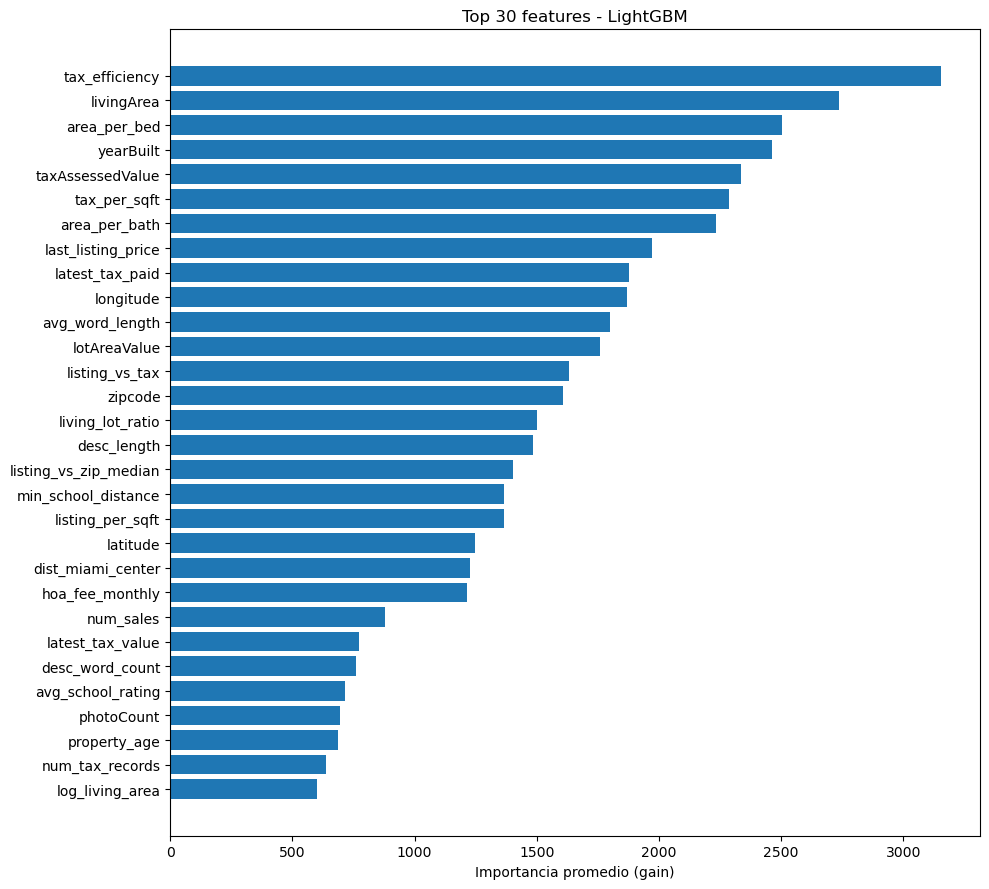

In [28]:
import matplotlib.pyplot as plt

# Promedio de importancias entre los 5 folds
fi_df = pd.DataFrame({
    "feature":    BASE_FEATURES,
    "importance": feat_importances / 5,
}).sort_values("importance", ascending=False)

print(fi_df.to_string(index=False))

# Top 30
top30 = fi_df.head(30)
fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top30["feature"][::-1], top30["importance"][::-1])
ax.set_xlabel("Importancia promedio (gain)")
ax.set_title("Top 30 features - LightGBM")
plt.tight_layout()
plt.show()